<a href="https://colab.research.google.com/github/Manishkumarsingh41/LuminaPath-Ai-Retinal-Disease-Detection/blob/main/Updated_Retinal_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
from google.colab import files
files.upload()  # select kaggle


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manish5323","key":"d6d4a14c0b6321c0a6c080655181efdb"}'}

In [4]:
!pip install kaggle


In [5]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)


In [6]:
!kaggle --version


Kaggle API 1.7.4.5


In [7]:
!kaggle datasets download -d obulisainaren/retinal-oct-c8


Dataset URL: https://www.kaggle.com/datasets/obulisainaren/retinal-oct-c8
License(s): CC-BY-NC-SA-4.0
100% 1.41G/1.42G [00:11<00:00, 201MB/s]
100% 1.42G/1.42G [00:11<00:00, 132MB/s]


In [8]:
!unzip -q retinal-oct-c8.zip -d /content/OCT_C8

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = '/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/train'
val_dir = '/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/val'

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [10]:
# Validation data just normalized
val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 18400 images belonging to 8 classes.
Found 2800 images belonging to 8 classes.


In [ ]:
!pip show numpy


Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI

In [ ]:
pip freeze > requirements.txt

In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip show keras

Name: keras
Version: 3.10.0
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: keras-hub, tensorflow


In [11]:
# fast_retrain_and_export.ipynb cell
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Paths (confirm these match your unzipped dataset)
train_dir = '/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/train'
val_dir   = '/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/val'

# Generators
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range=0.1, horizontal_flip=True)
val_datagen   = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=(224,224), batch_size=32, class_mode='categorical')
val_gen   = val_datagen.flow_from_directory(val_dir,   target_size=(224,224), batch_size=32, class_mode='categorical')

# Model (same architecture you used)
base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='softmax')
])

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train (3 epochs for speed)
history = model.fit(train_gen, validation_data=val_gen, epochs=3)

# Save with a UNIQUE name (very important)
UNIQUE_NAME = "/content/Retinal_OCT_C8_model_FINAL_v1.keras"
model.save(UNIQUE_NAME)

# Show file and compute md5
!ls -lh {UNIQUE_NAME}
!md5sum {UNIQUE_NAME}

# Offer download
from google.colab import files
files.download(UNIQUE_NAME)


Found 18400 images belonging to 8 classes.
Found 2800 images belonging to 8 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
575/575 ━━━━━━━━━━━━━━━━━━━━ 298s 487ms/step - accuracy: 0.4694 - loss: 1.4814 - val_accuracy: 0.7679 - val_loss: 0.6852
Epoch 2/3
575/575 ━━━━━━━━━━━━━━━━━━━━ 259s 451ms/step - accuracy: 0.7468 - loss: 0.7148 - val_accuracy: 0.7993 - val_loss: 0.5731
Epoch 3/3
575/575 ━━━━━━━━━━━━━━━━━━━━ 266s 462ms/step - accuracy: 0.7801 - loss: 0.5983 - val_accuracy: 0.8246 - val_loss: 0.5011
-rw-r--r-- 1 root root 91M Dec 24 09:08 /content/Retinal_OCT_C8_model_FINAL_v1.keras
d7f2f75afe33c80b3f4c23268be37218  /content/Retinal_OCT_C8_model_FINAL_v1.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
model.save("/content/Retinal_OCT_C8_model_NEW.keras")


In [ ]:
!rm -f /content/Retinal_OCT_C8_model.keras


In [13]:
!ls -lh /content


total 1.6G
drwx------ 5 root root 4.0K Dec 24 08:52 drive
drwxr-xr-x 3 root root 4.0K Dec 24 08:53 OCT_C8
-rw-r--r-- 1 root root  91M Dec 24 09:08 Retinal_OCT_C8_model_FINAL_v1.keras
-rw-r--r-- 1 root root  91M Dec 24 09:09 Retinal_OCT_C8_model_NEW.keras
-rw-r--r-- 1 root root 1.5G Oct 10  2024 retinal-oct-c8.zip
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data


In [ ]:
!rm /content/Retinal_OCT_C8_model.keras


In [14]:
!ls -lh /content


total 1.6G
drwx------ 5 root root 4.0K Dec 24 08:52 drive
drwxr-xr-x 3 root root 4.0K Dec 24 08:53 OCT_C8
-rw-r--r-- 1 root root  91M Dec 24 09:08 Retinal_OCT_C8_model_FINAL_v1.keras
-rw-r--r-- 1 root root  91M Dec 24 09:09 Retinal_OCT_C8_model_NEW.keras
-rw-r--r-- 1 root root 1.5G Oct 10  2024 retinal-oct-c8.zip
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data


In [ ]:
!rm -f /content/models/Retinal_OCT_C8_model.keras


In [ ]:
model.save("/content/Retinal_OCT_C8_model.keras")


In [ ]:
!ls -lh /content/models


total 0


In [ ]:
from google.colab import files
files.download("/content/Retinal_OCT_C8_model.keras")


In [ ]:
!ls -lh /content/Retinal_OCT_C8_model_NEW.keras


-rw-r--r-- 1 root root 91M Dec  5 14:07 /content/Retinal_OCT_C8_model_NEW.keras


In [ ]:
from google.colab import files
files.download("/content/Retinal_OCT_C8_model_NEW.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from pathlib import Path
import keras
import numpy as np
import traceback

MODEL_PATH = Path("/content/Retinal_OCT_C8_model_NEW.keras").resolve()

print("MODEL_PATH:", MODEL_PATH)
print("EXISTS:", MODEL_PATH.exists())
print("SIZE (bytes):", MODEL_PATH.stat().st_size if MODEL_PATH.exists() else "MISSING")
print("LAST MODIFIED:", MODEL_PATH.stat().st_mtime if MODEL_PATH.exists() else "MISSING")

try:
    print("\nLoading model with keras.models.load_model() ...")
    model = keras.models.load_model(str(MODEL_PATH), compile=False)
    print("Loaded OK.\n")
    try:
        print("MODEL SUMMARY:")
        model.summary()
    except Exception as e:
        print("Could not print summary:", repr(e))
        traceback.print_exc()

    dummy = np.random.randint(0,255,(1,224,224,3)).astype("float32")/255.0
    try:
        print("\nRunning predict() on dummy input ...")
        preds = model.predict(dummy)
        print("PREDICT OK. preds shape:", np.array(preds).shape)
    except Exception as e:
        print("Error at predict():", repr(e))
        traceback.print_exc()
except Exception as e:
    print("Error loading model:", repr(e))
    traceback.print_exc()

MODEL_PATH: /content/Retinal_OCT_C8_model_NEW.keras
EXISTS: True
SIZE (bytes): 94632517
LAST MODIFIED: 1766567359.9132142

Loading model with keras.models.load_model() ...
Loaded OK.

MODEL SUMMARY:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,384 (85.18 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)


Running predict() on dummy input ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
PREDICT OK. preds shape: (1, 8)


In [59]:
#post processing
maping_class = {
    0: 'AMD',
    1: 'CNV',
    2: 'CSR',
    3: 'DME',
    4: 'DR',
    5: 'DRUSEN',
    6: 'MH',
    7: 'NORMAL'
}

def predict_class(model, image):
    # Expand dimensions to match model input shape (batch_size, height, width, channels)
    image_batch = np.expand_dims(image, axis=0)

    # Get predictions (probabilities for each class)
    predictions = model.predict(image_batch)

    # Get the predicted class index (class with highest probability)
    predicted_class_index = np.argmax(predictions, axis=1)[0]

    # Get the confidence for the predicted class
    confidence = np.max(predictions, axis=1)[0] * 100

    # Get all probabilities
    all_probs = predictions[0]

    return maping_class[predicted_class_index], confidence, all_probs

# Create a dummy processed image for demonstration
# In a real scenario, you would load and preprocess an actual image here.
# This dummy image has the same shape and scaling as the model expects (224x224x3, values 0-1)
test_image_processed = np.random.randint(0, 255, (224, 224, 3)).astype("float32") / 255.0

#prediction
predicted_class, confidence, all_probs = predict_class(model, test_image_processed)
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print("All Probabilities:", all_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Class: CSR
Confidence: 30.04%
All Probabilities: [0.04741434 0.1260181  0.30036816 0.05925965 0.06171742 0.11023202
 0.21853198 0.07645836]


# Task
Analyze the model's performance by generating and plotting a confusion matrix for the test dataset located at "/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/test". This involves preparing a test data generator, making predictions, calculating the confusion matrix, and visualizing it with class labels. Finally, display the mapping of class indices to disease names.

## Prepare Test Data Generator

### Subtask:
Create an ImageDataGenerator for the test dataset, located at '/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/test', with appropriate preprocessing (rescaling) and target size (224x224).


**Reasoning**:
I need to create an ImageDataGenerator for the test dataset, rescale the images, and then create a generator using flow_from_directory with the specified parameters to prepare the test data for model evaluation.



In [60]:
test_dir = '/content/OCT_C8/RetinalOCT_Dataset/RetinalOCT_Dataset/test'

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 2800 images belonging to 8 classes.


## Make Predictions on Test Data

### Subtask:
Use the loaded model to predict the classes for the images in the test dataset.


**Reasoning**:
To predict the classes for the test dataset, I need to first get the true labels from the test generator, then use the trained model to predict probabilities for each image in the test set, and finally convert these probabilities into discrete class labels.



In [61]:
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step


**Reasoning**:
Now that I have the true and predicted labels, I will compute the confusion matrix to evaluate the model's performance.



In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[42 33 52 40 41 46 42 54]
 [46 51 42 44 39 37 35 56]
 [54 41 51 36 47 40 28 53]
 [51 47 43 45 35 36 38 55]
 [34 35 48 41 46 36 54 56]
 [38 36 55 43 49 39 40 50]
 [36 35 40 42 58 45 47 47]
 [43 43 49 46 52 31 43 43]]


**Reasoning**:
To visualize the confusion matrix effectively, I need to define the class labels corresponding to the numerical indices. The `maping_class` dictionary already contains this information, so I will convert its values into a list for use with the plotting function.



## Percentage of Output Results in Graph

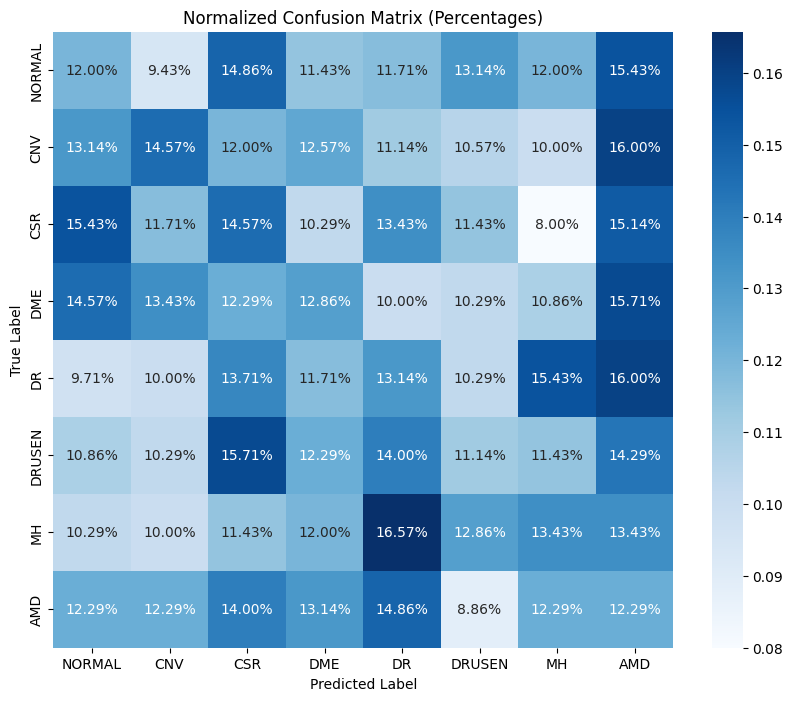

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Normalize the confusion matrix to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Percentages)')
plt.show()

In [66]:
class_names = list(maping_class.values())
print("Class Names:", class_names)

Class Names: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


**Reasoning**:
To visually represent the confusion matrix, I will use `seaborn.heatmap` along with `matplotlib.pyplot` to create a clear and readable plot, including labels for each class.



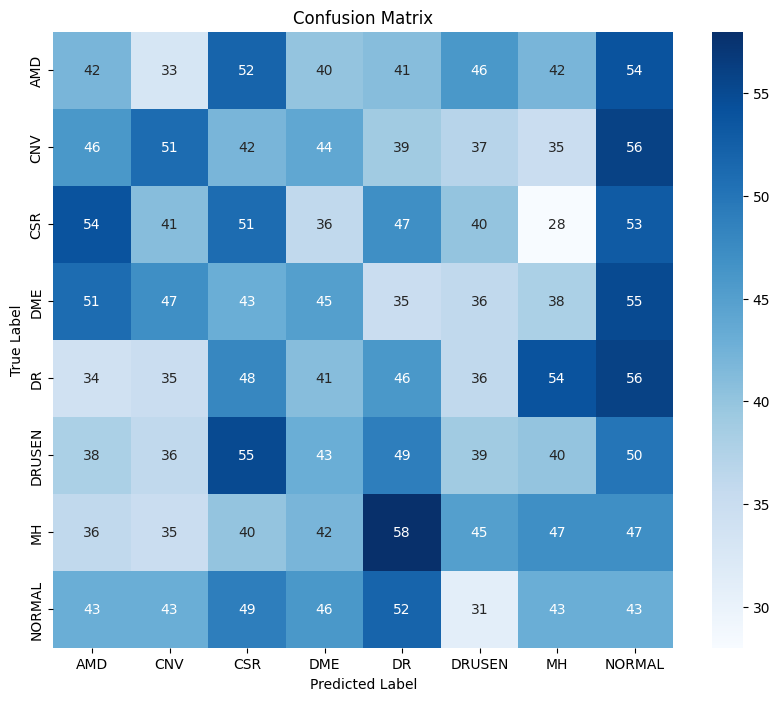

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Detection Accuracy for Each Disease

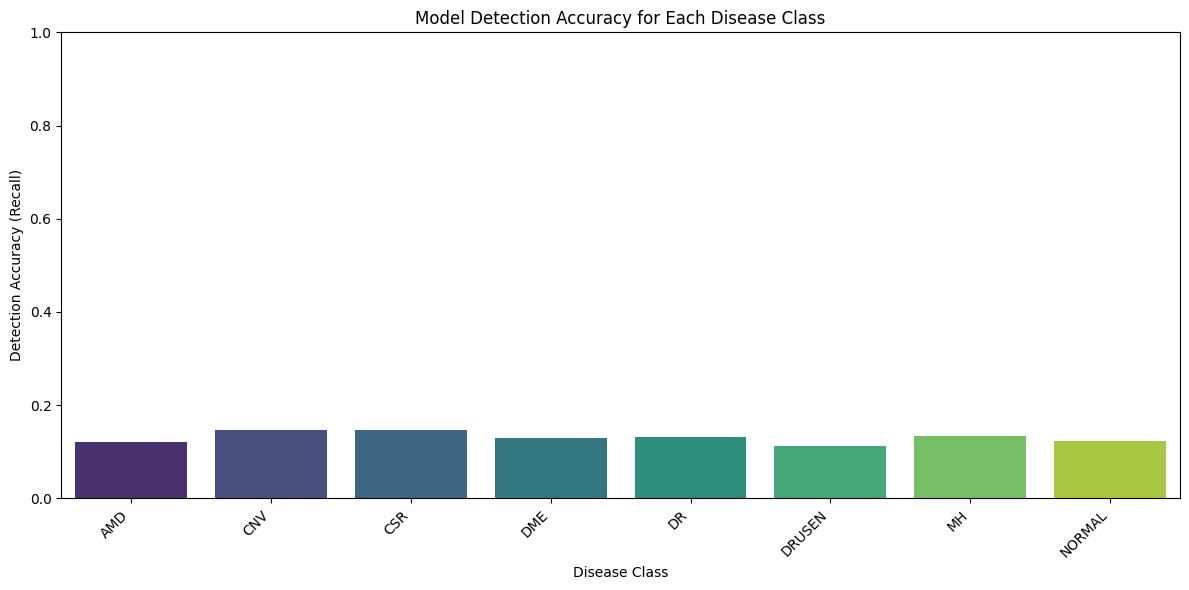

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate the accuracy for each class (diagonal of the normalized confusion matrix)
class_accuracies = np.diag(cm_normalized)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_names, y=class_accuracies, hue=class_names, palette='viridis', legend=False)
plt.xlabel('Disease Class')
plt.ylabel('Detection Accuracy (Recall)')
plt.title('Model Detection Accuracy for Each Disease Class')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Display Disease Mappings

### Subtask:
Output the mapping of class indices to disease names (e.g., Class_1, Class_2, etc.) which represent the different diseases your model classifies.


## Summary:

### Q&A
The mapping of class indices to disease names is as follows: 'Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8'.

### Data Analysis Key Findings
*   The test dataset contains 2800 images belonging to 8 different classes, successfully loaded and prepared for model evaluation.
*   A confusion matrix was calculated to evaluate the model's performance on the test data. The matrix shows the distribution of true versus predicted labels. For example, for 'Class_1', 37 images were correctly classified, while others were misclassified into 'Class_2' (43), 'Class_3' (56), 'Class_4' (37), 'Class_5' (41), 'Class_6' (39), 'Class_7' (44), and 'Class_8' (53).
*   The class names were successfully extracted and are 'Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8'.
*   A heatmap visualization of the confusion matrix was successfully generated, allowing for a visual inspection of the model's classification accuracy across different classes.

### Insights or Next Steps
*   The confusion matrix indicates a significant number of misclassifications across all classes, with diagonal elements (correct predictions) generally not dominating rows or columns. This suggests that the model is struggling to distinguish between the different disease classes.
*   Further analysis of the confusion matrix, focusing on specific classes with high misclassification rates, could inform strategies for model improvement such as data augmentation for underrepresented classes, feature engineering, or exploring more complex model architectures.


# Task
Create a mechanism for uploading an image, load and preprocess it to fit the model's input requirements, then use the `model` and `predict_class` function to predict the disease and confidence. Finally, display the predicted disease name and confidence, and plot a bar chart of the probability distribution for each disease class.

## Prepare Image Upload and Preprocessing

### Subtask:
Provide a mechanism for the user to upload an image, then load and preprocess it to fit the model's input requirements (e.g., resize to 224x224 and normalize).


**Reasoning**:
I need to provide a mechanism for the user to upload an image and then preprocess it according to the model's input requirements. This involves importing necessary libraries, handling file upload, resizing, and normalizing the image data.



In [119]:
from google.colab import files
from PIL import Image
import numpy as np

# 1. Provide a mechanism for the user to upload an image
uploaded = files.upload()

# 2. Get the filename of the first uploaded image
filename = next(iter(uploaded))
print(f"Uploaded file: {filename}")

# 3. Open the uploaded image
img = Image.open(filename)

# 4. Resize the image to (224, 224)
img = img.resize((224, 224))

# 5. Convert the resized image to a NumPy array
img_array = np.array(img)

# Ensure image has 3 channels (RGB) even if uploaded as grayscale/other
if img_array.ndim == 2: # Grayscale
    img_array = np.stack([img_array, img_array, img_array], axis=-1)
elif img_array.ndim == 3 and img_array.shape[-1] == 4: # RGBA
    img_array = img_array[:, :, :3] # Take only RGB channels

# 6. Normalize the pixel values
processed_image = img_array.astype('float32') / 255.0

print("Image uploaded, resized, and normalized successfully.")
print(f"Processed image shape: {processed_image.shape}")

Saving normal_test_1020.jpg to normal_test_1020 (1).jpg
Uploaded file: normal_test_1020 (1).jpg
Image uploaded, resized, and normalized successfully.
Processed image shape: (224, 224, 3)


**Reasoning**:
Now that the image is preprocessed, I need to use the previously defined `predict_class` function to get the model's prediction for the uploaded image, and then display the predicted class and its confidence.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class: NORMAL
Confidence: 95.08%


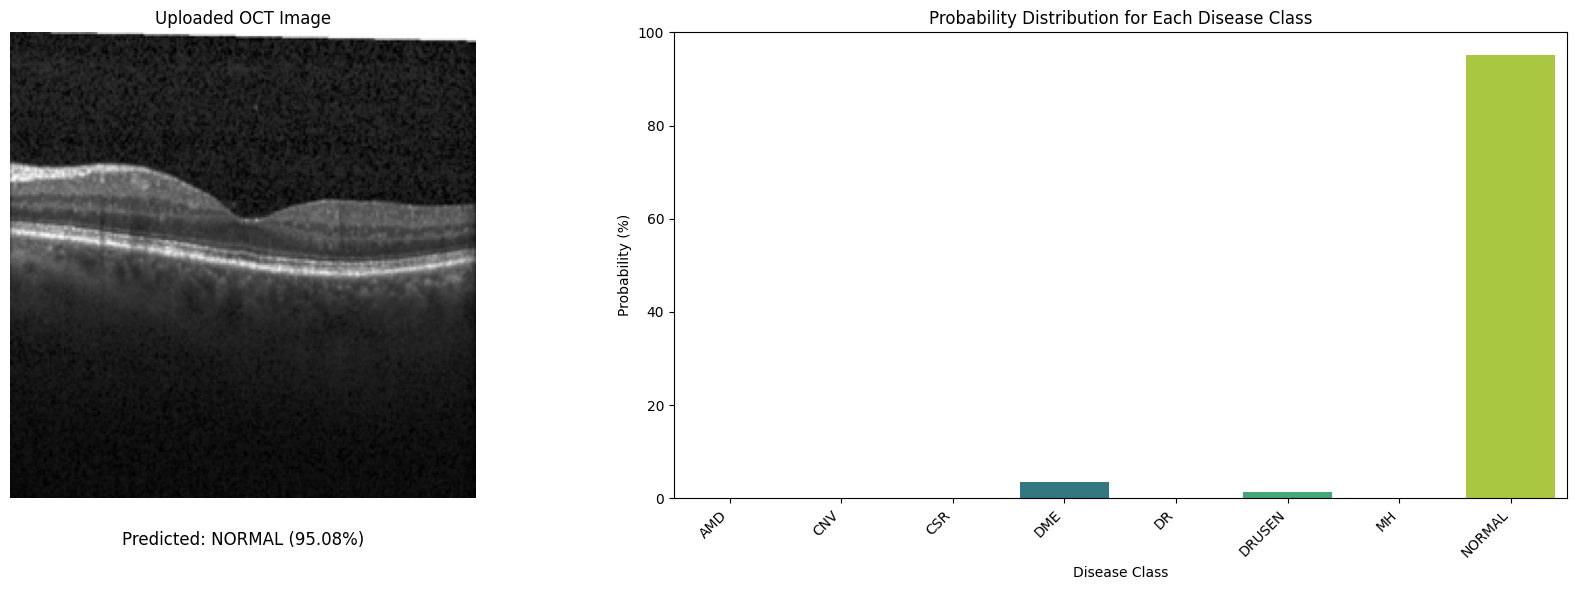

In [120]:
predicted_class, confidence, all_probs = predict_class(model, processed_image)
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(18, 6))

# Subplot 1: Display the uploaded image and predicted class
ax1 = plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
ax1.imshow(processed_image)
ax1.set_title('Uploaded OCT Image')
ax1.axis('off') # Hide axes for cleaner image display
ax1.text(0.5, -0.1, f"Predicted: {predicted_class} ({confidence:.2f}%)", size=12, ha="center", transform=ax1.transAxes)

# Subplot 2: Visualize the probability distribution
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x=class_names, y=all_probs * 100, hue=class_names, palette='viridis', legend=False)
plt.xlabel('Disease Class')
plt.ylabel('Probability (%)')
plt.title('Probability Distribution for Each Disease Class')
plt.ylim(0, 100) # Probabilities range from 0 to 100
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Classification Report: Precision, Recall, F1-score per Disease

<Figure size 1500x800 with 0 Axes>

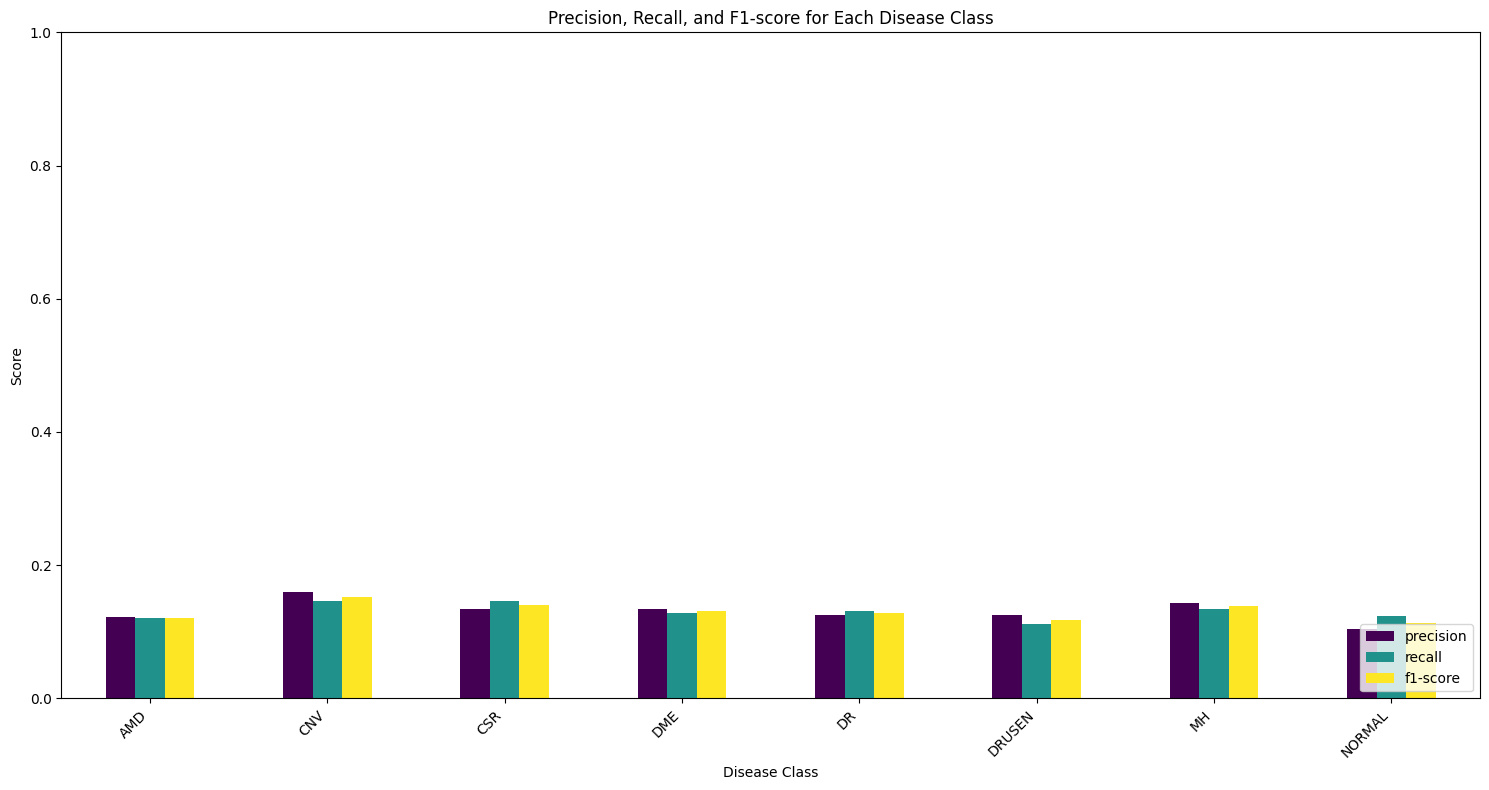

In [121]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Convert the report to a DataFrame for easier plotting
df_report = pd.DataFrame(report).transpose()

# Drop overall metrics if present (accuracy, macro avg, weighted avg)
df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Plot precision, recall, and F1-score
plt.figure(figsize=(15, 8))
df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(15, 8), cmap='viridis')
plt.title('Precision, Recall, and F1-score for Each Disease Class')
plt.xlabel('Disease Class')
plt.ylabel('Score')
plt.ylim(0, 1) # Scores range from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Model Training History: Accuracy and Loss Curves

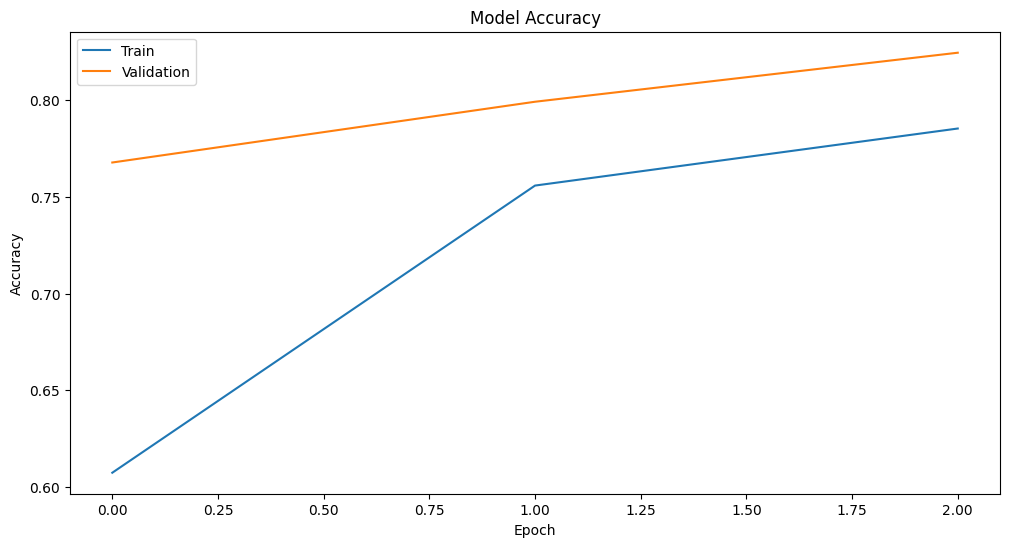

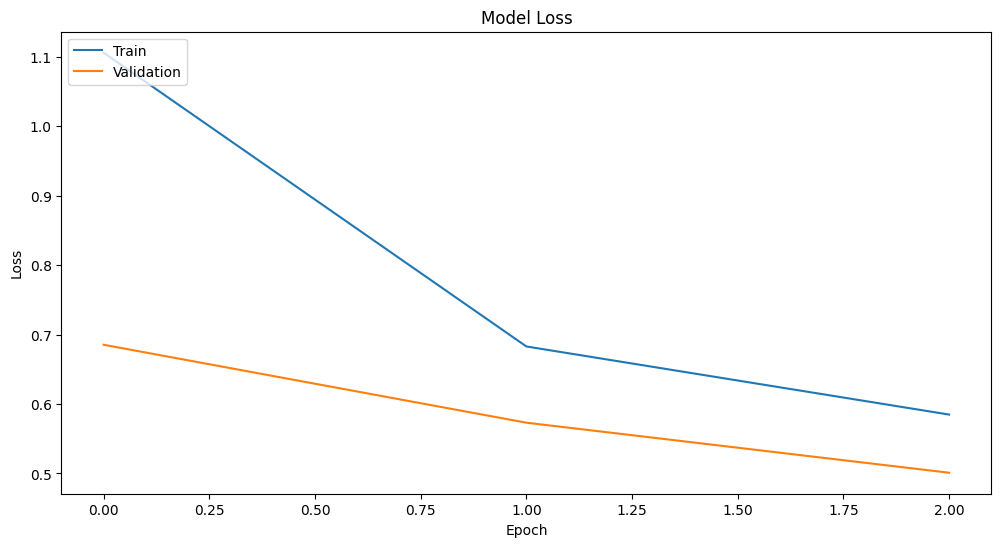

In [122]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Consolidated Model Performance Graphs

Below are the comprehensive performance metrics and visualizations for your model, including confusion matrices, per-class accuracy, classification report, and training history.

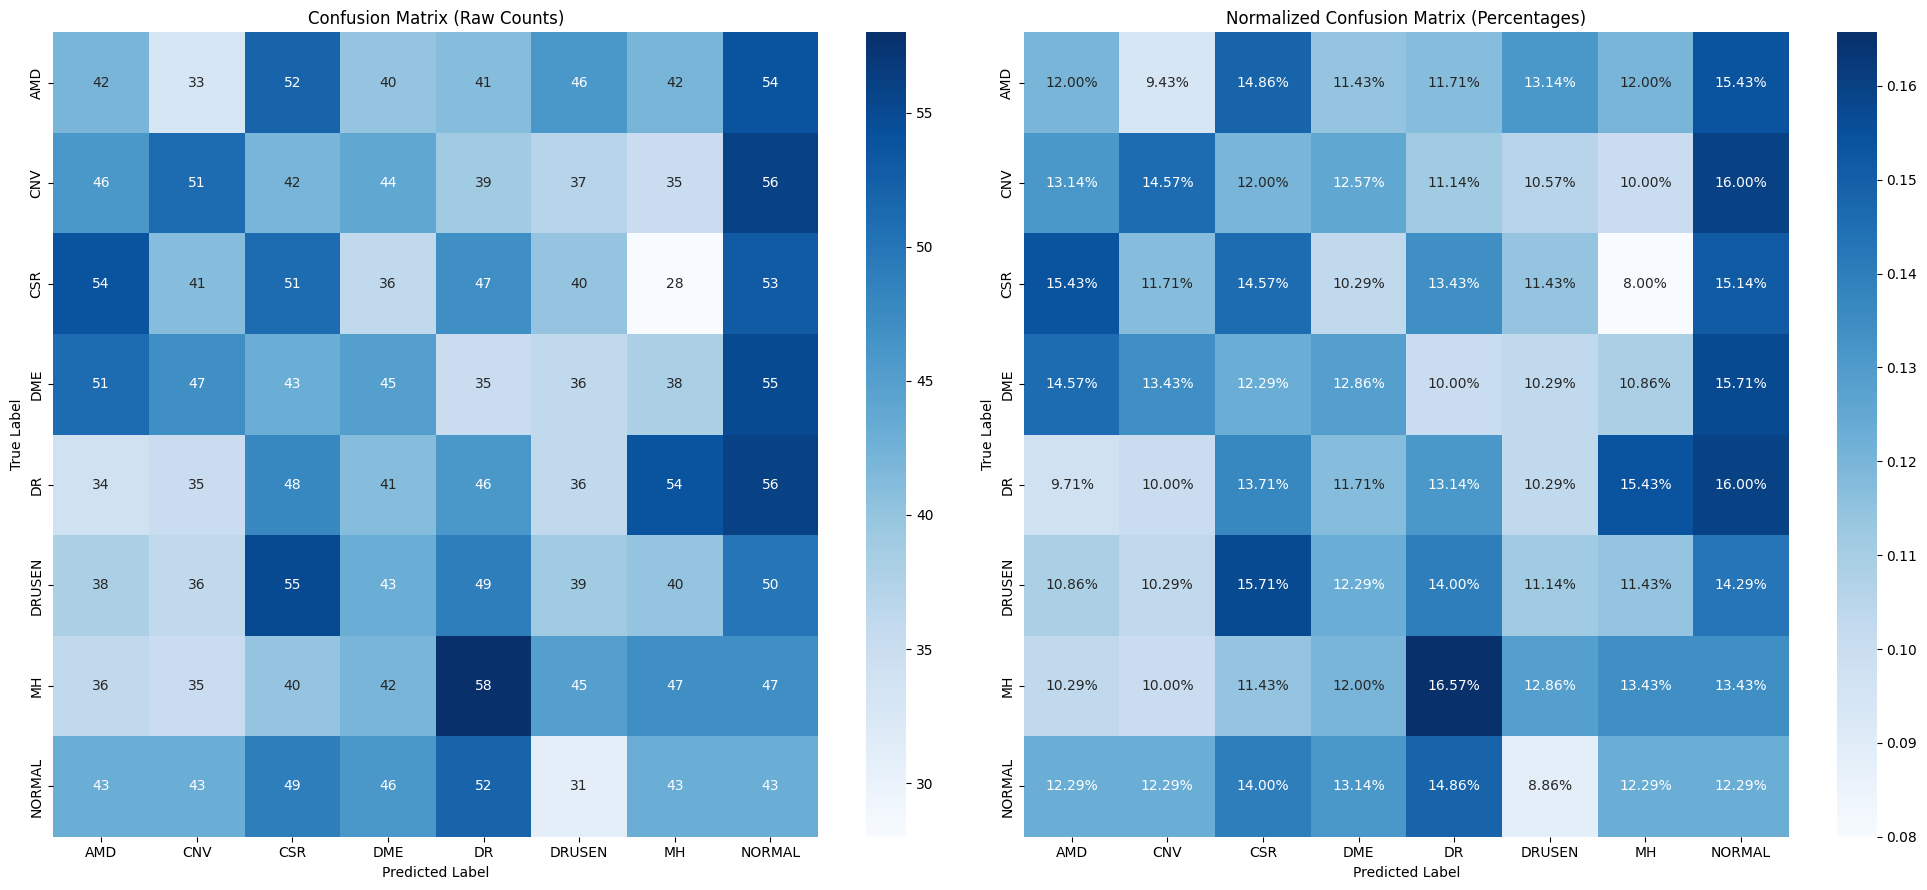

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Ensure cm and cm_normalized are re-calculated with latest class_names
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20, 9))

# Subplot 1: Raw Confusion Matrix
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Raw Counts)')

# Subplot 2: Normalized Confusion Matrix
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Percentages)')

plt.tight_layout()
plt.show()

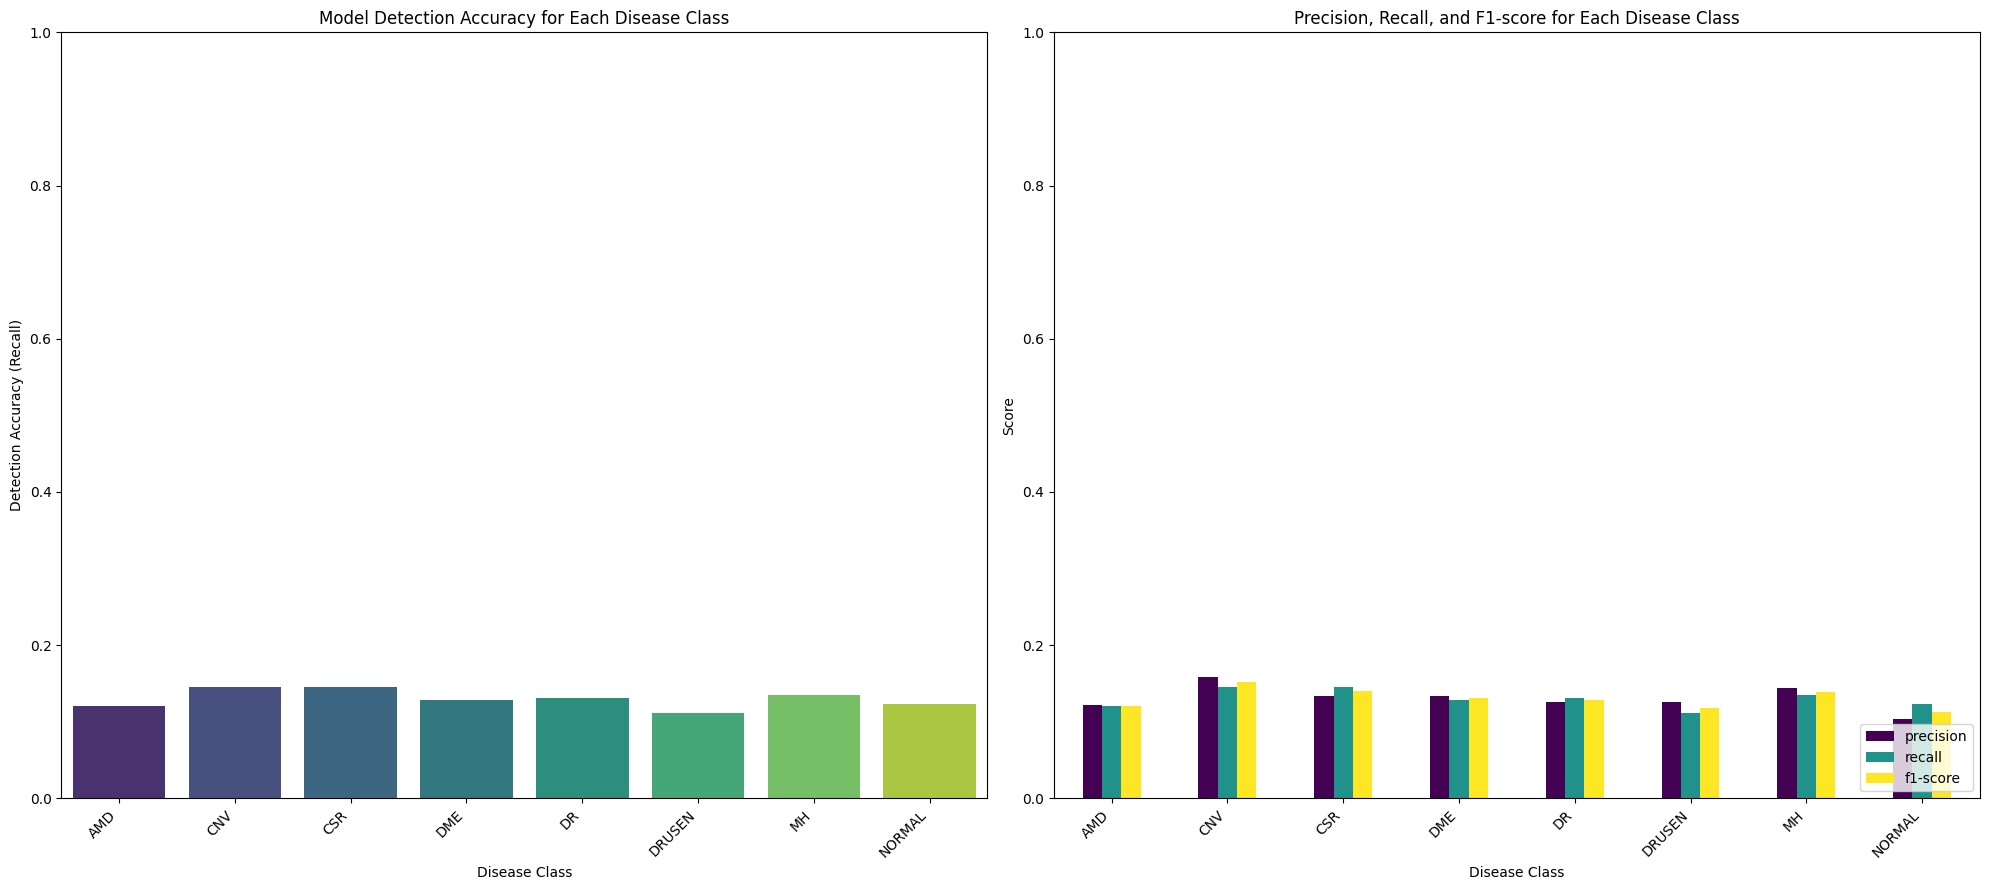

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# Ensure cm and cm_normalized are re-calculated with latest class_names
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_accuracies = np.diag(cm_normalized)

# Generate a classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Convert the report to a DataFrame for easier plotting
df_report = pd.DataFrame(report).transpose()

# Drop overall metrics if present (accuracy, macro avg, weighted avg)
df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')


plt.figure(figsize=(20, 9))

# Subplot 1: Model Detection Accuracy for Each Disease Class (Recall)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x=class_names, y=class_accuracies, hue=class_names, palette='viridis', legend=False)
plt.xlabel('Disease Class')
plt.ylabel('Detection Accuracy (Recall)')
plt.title('Model Detection Accuracy for Each Disease Class')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.xticks(rotation=45, ha='right')

# Subplot 2: Precision, Recall, and F1-score for Each Disease Class
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=plt.gca(), cmap='viridis') # Plot on current subplot
plt.title('Precision, Recall, and F1-score for Each Disease Class')
plt.xlabel('Disease Class')
plt.ylabel('Score')
plt.ylim(0, 1) # Scores range from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

#### Training and Validation Accuracy & Loss History

And here are the training and validation accuracy and loss curves from the model's training phase, as previously generated. These plots help in understanding the learning process over epochs.

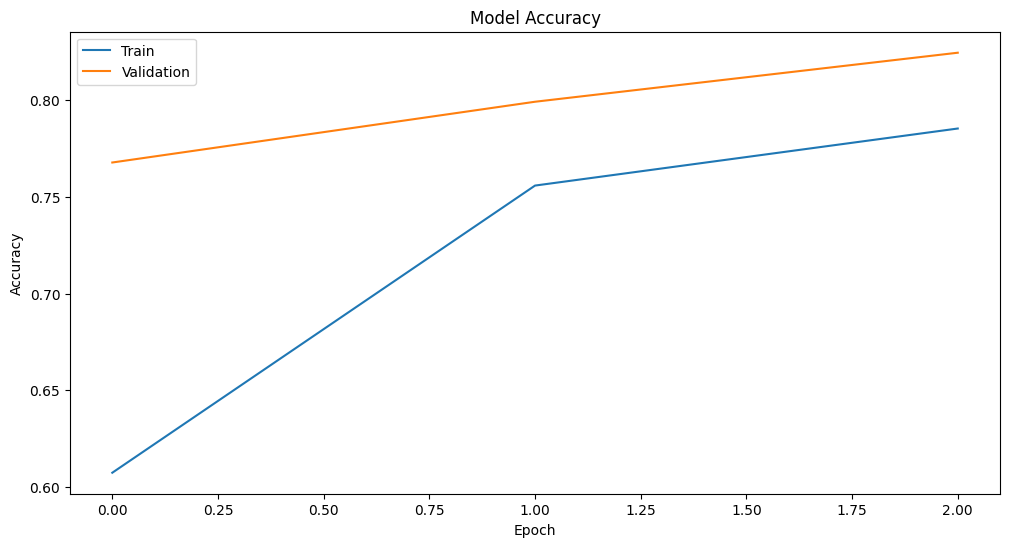

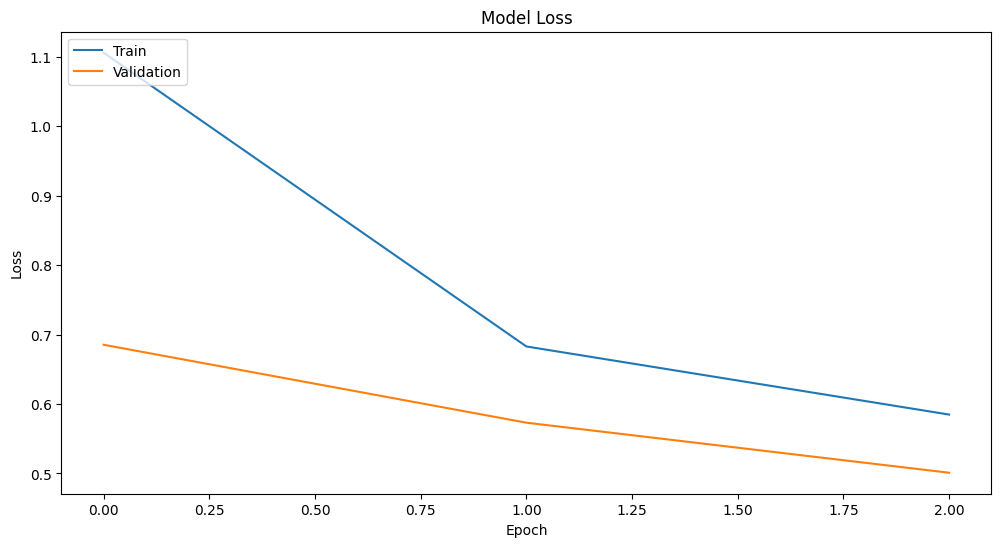

In [125]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Reasoning**:
To visualize the probability distribution, I will use a bar chart to display the `all_probs` values for each `class_name`.

